# Example climb: nonlinear feature interactions

## 1. Notebook setup

### 1.1. Imports

In [1]:
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import linregress, pearsonr
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from hill_climber import HillClimber

### 1.2. Run configuration

In [ ]:
# Input dataset size
n = 5000

# Hill climber parameters
max_time=30                               # Maximum time (in minutes) to run optimization
n_replicas=20                             # Number of replicas (workers) in parallel tempering
initial_step_spread=0.5                   # Fraction of input range to sample initially
final_step_spread=0.01                    # Fraction of input range to sample finally
step_spread_scheme='zeno'                 # Cooling scheme for step spread
exchange_interval=10000                   # Steps between replica exchange attempts
T_max_initial=100                         # Replica initial max temperature
T_min_initial=1e-2                        # Replica initial min temperature
T_max_final=0                             # Replica final max temperature
T_min_final=0                             # Replica final min temperature
db_step_interval=1000                     # Steps between database writes
db_path='../data/feature_interactions.db' # Path to results database

# Filename for results checkpoint
output_file = '../data/feature_interaction_results.pkl'

# Set True to re-run optimization, False to load checkpoint from disk
run_optimization = True

# Set random seed for reproducibility
np.random.seed(315)

### 1.3. Input distributions

In [3]:
# Create input distributions: 3 features (x1, x2, x3) and 1 label (y)
data = pd.DataFrame({
    'x1': np.random.uniform(-1, 1, n),
    'x2': np.random.uniform(-1, 1, n),
    'x3': np.random.uniform(-1, 1, n),
    'y': np.random.uniform(-1, 1, n)
})

print('Initial data statistics:')
print(data.describe())
print('\nInitial correlations with label:')

for col in ['x1', 'x2', 'x3']:
    corr, _ = pearsonr(data[col], data['y'])
    print(f"{col}-y: {corr:.4f}")

# Check initial linear regression R²
X = data[['x1', 'x2', 'x3']].values
y = data['y'].values

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)

Initial data statistics:
                x1           x2           x3            y
count  5000.000000  5000.000000  5000.000000  5000.000000
mean      0.004924     0.005183    -0.003117    -0.002754
std       0.576225     0.577811     0.584424     0.582827
min      -0.999388    -0.999139    -0.999889    -0.999236
25%      -0.504969    -0.496002    -0.518669    -0.514382
50%       0.016247     0.006149     0.002680    -0.006266
75%       0.506426     0.513404     0.507413     0.505310
max       0.999923     0.999539     0.999552     0.999701

Initial correlations with label:
x1-y: 0.0048
x2-y: -0.0030
x3-y: -0.0061


## 2. Optimize for weak individual correlations but strong collective prediction

### 2.1. Objective function

In [4]:
def objective_feature_interactions(x1, x2, x3, y):
    '''Maximize multiple linear regression R² while minimizing individual feature-label correlations.
    
    This creates datasets where features interact to predict the label, but individual features
    alone are poor predictors. This demonstrates the importance of feature interactions.
    
    Args:
        x1, x2, x3: Feature variables (array-like)
        y: Label variable (array-like)
    
    Returns:
        Tuple of (metrics_dict, objective_value)
    '''
    
    # Convert to numpy arrays
    x1 = np.asarray(x1)
    x2 = np.asarray(x2)
    x3 = np.asarray(x3)
    y = np.asarray(y)
    
    # Calculate individual Pearson correlations with label
    x1_y_r, _ = pearsonr(x1, y)
    x2_y_r, _ = pearsonr(x2, y)
    x3_y_r, _ = pearsonr(x3, y)
    
    # Average R² of individual features (want this LOW)
    avg_individual_r = np.mean([x1_y_r**2, x2_y_r**2, x3_y_r**2])

    # Calculate pairwise feature correlations
    x1_x2_r, _ = pearsonr(x1, x2)
    x1_x3_r, _ = pearsonr(x1, x3)
    x2_x3_r, _ = pearsonr(x2, x3)

    # Average R² of feature-feature correlations (want this LOW)
    avg_feature_r = np.mean([x1_x2_r**2, x1_x3_r**2, x2_x3_r**2])

    # Train and score the model
    x = np.column_stack([x1, x2, x3])
    model = DecisionTreeRegressor(max_depth=5).fit(x, y)
    mlr_r2 = r2_score(y, model.predict(x))
    
    # Calculate objective
    objective = mlr_r2 - (avg_individual_r * 0.25) - (avg_feature_r * 0.25)
    
    # Compile metrics
    metrics = {
        'Model R²': float(mlr_r2),
        'Avg individual R²': float(avg_individual_r),
        'Avg feature R²': float(avg_feature_r),
    }
    
    return metrics, float(objective)

### 2.2. Hill climbing run

In [5]:
if run_optimization:

    # Create HillClimber instance with replica exchange
    climber = HillClimber(
        data=data,
        objective_func=objective_feature_interactions,
        initial_step_spread=initial_step_spread,
        final_step_spread=final_step_spread,
        step_spread_scheme=step_spread_scheme,
        T_max_initial=T_max_initial,
        T_min_initial=T_min_initial,
        T_max_final=T_max_final,
        T_min_final=T_min_final,
        exchange_interval=exchange_interval,
        db_step_interval=db_step_interval,
        max_time=max_time,
        n_replicas=n_replicas,
        db_path=db_path
    )

    # Run optimization
    best_data_df = climber.climb()

    # Save checkpoint after completion
    climber.checkpoint_file = output_file
    climber.save_checkpoint(output_file)

HillClimber Configuration

Data shape:           (5000, 4)
Optimization mode:    maximize
Max runtime:          10 minutes

Temperature settings:
  T_min_initial:       0.01
  T_max_initial:       100
  T_min_final:         1e-15
  T_max_final:         1e-15
  Ladder spacing:      geometric
  Cooling schedule:    geometric

Replica exchange:
  Number of replicas: 20
  Exchange interval:  10000 steps
  Exchange strategy:  even_odd
  Worker processes:   20

Perturbation settings:
  Initial step spread: 0.5 (fraction of range)
  Final step spread:   0.01 (fraction at end of run)
  Cooling scheme:      zeno
  Perturb fraction:    0.001

Database settings:
  Enabled:            True
  Path:               ../data/feature_interactions.db
  Step interval:      1000



### 2.3. Results

In [6]:
# If we just re-ran the optimization, collect results from the climber
if run_optimization:
    replicates = climber.get_replicas()

# Otherwise, load from saved results
else:

    # Load the results checkpoint
    try:
        with open(output_file, 'rb') as f:
            results = pickle.load(f)

        # Get the winning replica's best data
        best_replica = max(results['replicas'], key=lambda r: r['best_objective'])

        best_data_df = pd.DataFrame(
            best_replica['best_data'],
            columns=data.columns
        )

        # Collect best data from each replica
        replicas = []

        for replica_data in results['replicas']:
            replica_df = pd.DataFrame(
                replica_data['best_data'],
                columns=data.columns
            )
            replicas.append(replica_df)

    except FileNotFoundError:
        print('Error: checkpoint file not found.')
        print('Please run the optimization by setting run_optimization = True in the run configuration cell.')
    
        results_df = pd.DataFrame()

In [7]:
train_df, test_df = train_test_split(best_data_df, random_state=315)
train_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)
train_df.head()

,x1,x2,x3,y
0,-0.100681,0.649427,-0.178099,0.786022
1,0.604874,-0.648511,-0.300758,0.074806
2,-0.845189,0.325763,-0.094845,-0.821567
3,0.325295,0.714176,0.766071,-0.599862
4,-0.728549,0.299329,-0.851765,-0.854822


#### 2.3.1. Gradient boosting regression

In [8]:
model = GradientBoostingRegressor()
model.fit(train_df[['x1', 'x2', 'x3']].values, train_df['y'].values)

y_pred = model.predict(test_df[['x1', 'x2', 'x3']].values)
residuals = test_df['y'].values - y_pred
standardized_residuals = (residuals - np.mean(residuals)) / np.std(residuals)
root_standardized_residuals = np.sqrt(np.abs(standardized_residuals))
r2 = r2_score(test_df['y'].values, y_pred)
print(f'Model R²: {r2:.2f}')

Model R²: 0.45


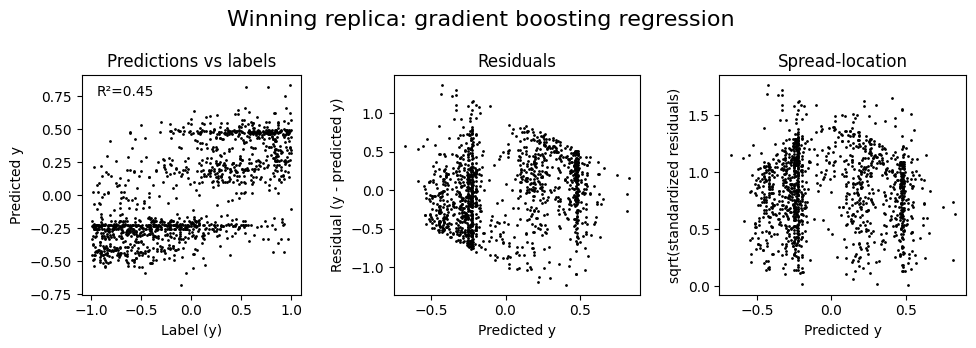

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3.5))
fig.suptitle('Winning replica: gradient boosting regression', fontsize=16)

axs[0].set_title('Predictions vs labels')
stats=f'R²={r2:.2f}'

axs[0].annotate(
    xy=(-0.95, np.max(y_pred)),
    text=stats,
    ha='left', va='top',
    bbox=dict(boxstyle='square', fc='white', ec='white')
)

axs[0].scatter(test_df['y'].values, y_pred, s=1, c='black')
axs[0].set_xlabel('Label (y)')
axs[0].set_ylabel('Predicted y')
axs[0].set_box_aspect(1)

axs[1].set_title('Residuals')
axs[1].scatter(y_pred, residuals, s=1, c='black')
axs[1].set_xlabel('Predicted y')
axs[1].set_ylabel('Residual (y - predicted y)')
axs[0].set_box_aspect(1)

axs[2].set_title('Spread-location')
axs[2].scatter(y_pred, root_standardized_residuals, s=1, c='black')
axs[2].set_xlabel('Predicted y')
axs[2].set_ylabel('sqrt(standardized residuals)')
axs[0].set_box_aspect(1)

plt.tight_layout()
plt.show()

#### 2.3.2. Feature-label correlations

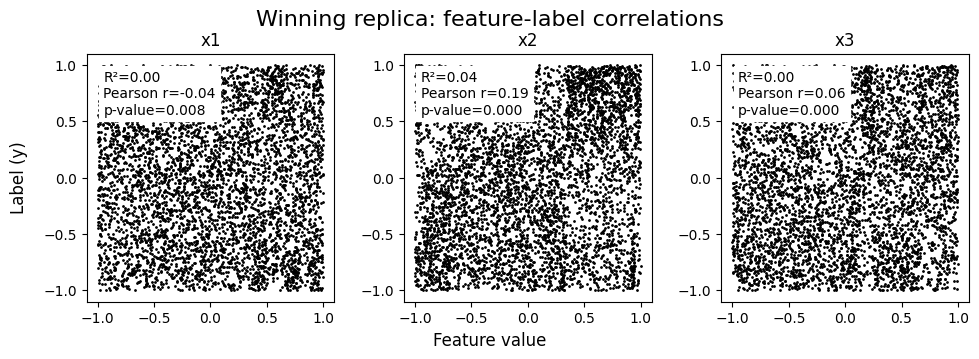

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3.5))
fig.suptitle('Winning replica: feature-label correlations', fontsize=16)
fig.supxlabel('Feature value')
fig.supylabel('Label (y)')

for i, feature in enumerate(['x1', 'x2', 'x3']):

    slope, intercept, r_value, p_value, std_err = linregress(best_data_df[feature], best_data_df['y'])
    stats=f'R²={r_value**2:.2f}\nPearson r={r_value:.2f}\np-value={p_value:.3f}'

    axs[i].set_title(feature)

    axs[i].annotate(
        xy=(-0.95, 0.95),
        text=stats,
        ha='left', va='top',
        bbox=dict(boxstyle='square', fc='white', ec='white')
    )

    axs[i].scatter(best_data_df[feature], best_data_df['y'], s=1, c='black')
    axs[i].set_aspect('equal')

plt.tight_layout()
plt.show()

#### 2.3.3. Feature-feature correlations

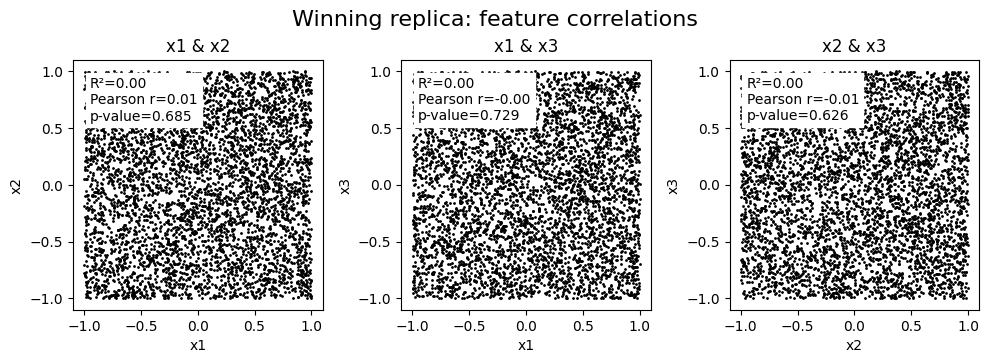

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3.5))
fig.suptitle('Winning replica: feature correlations', fontsize=16)

for i, features in enumerate([['x1', 'x2'],['x1', 'x3'], ['x2', 'x3']]):

    slope, intercept, r_value, p_value, std_err = linregress(
        best_data_df[features[0]],
        best_data_df[features[1]]
    )

    stats=f'R²={r_value**2:.2f}\nPearson r={r_value:.2f}\np-value={p_value:.3f}'

    axs[i].set_title(f'{features[0]} & {features[1]}')
    axs[i].annotate(
        xy=(-0.95, 0.95),
        text=stats,
        ha='left', va='top', 
        bbox=dict(boxstyle='square', fc='white', ec='white')
    )
    axs[i].scatter(best_data_df[features[0]], best_data_df[features[1]], s=1, c='black')
    axs[i].set_xlabel(features[0])
    axs[i].set_ylabel(features[1])
    axs[i].set_aspect('equal')

plt.tight_layout()
plt.show()

#### 2.3.4. Replicate regression models

In [12]:
replicas = climber.get_replicas()
print(f'Have {len(replicas)} replicas')

Have 20 replicas


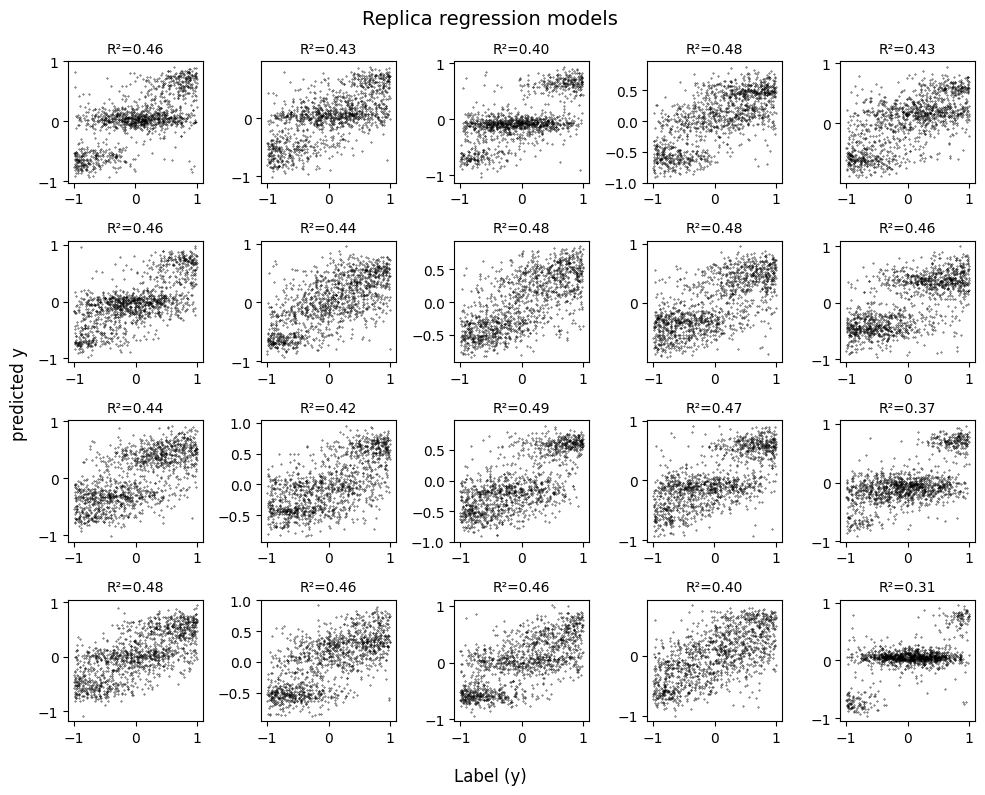

In [13]:
replicates = climber.get_replicas()
ncols = 5
nrows = len(replicates) // ncols

if len(replicates) % ncols != 0:
    nrows+=1

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*2, nrows*2))
axs = axs.flatten()

fig.suptitle('Replica regression models', fontsize=14)
fig.supxlabel('Label (y)', fontsize=12)
fig.supylabel('predicted y', fontsize=12)

for i, replica in enumerate(replicas):

    replicate_train_df, replicate_test_df = train_test_split(replica, random_state=315)

    model = GradientBoostingRegressor(n_estimators=50, max_depth=10)
    model.fit(replicate_train_df[['x1', 'x2', 'x3']].values, replicate_train_df['y'].values)
    y_pred = model.predict(replicate_test_df[['x1', 'x2', 'x3']].values)
    r2 = r2_score(replicate_test_df['y'].values, y_pred)

    axs[i].set_title(f'R²={r2:.2f}', fontsize=10)
    axs[i].scatter(replicate_test_df['y'], y_pred, s=0.1, c='black')

plt.tight_layout()
plt.show()